In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs('outputs', exist_ok=True)

In [12]:

tickets = pd.read_csv('tickets.csv')
teams   = pd.read_csv('teams.csv')

print(f'Raw tickets rows  : {len(tickets)} ')
print(f'Teams rows        : {len(teams)} ')

tickets['resolution_hours'] = pd.to_numeric(tickets['resolution_hours'])
tickets['satisfaction']     = pd.to_numeric(tickets['satisfaction'])
print(f'\nDtype check — resolution_hours: {tickets["resolution_hours"].dtype}, '
      f'satisfaction: {tickets["satisfaction"].dtype}')

tickets

Raw tickets rows  : 13 
Teams rows        : 4 

Dtype check — resolution_hours: int64, satisfaction: int64


,ticket_id,month,team_id,channel,resolution_hours,satisfaction
0,1,Jan,T1,Email,12,4
1,2,Jan,T2,Chat,28,3
2,3,Jan,T3,Phone,36,2
3,4,Jan,T4,Email,20,4
4,5,Feb,T1,Chat,8,5
5,6,Feb,T2,Phone,30,3
6,7,Feb,T3,Email,18,4
7,8,Feb,T4,Chat,40,2
8,9,Mar,T1,Phone,16,4
9,10,Mar,T2,Email,22,4


In [3]:
# Remove exact duplicate row
tickets_clean = tickets.drop_duplicates()

merged = tickets_clean.merge(teams, on='team_id', how='left')

assert len(merged) == 12, f'Expected 12 rows, got {len(merged)}'
assert merged['department'].isna().sum() == 0, 'Unmatched team_id — NaN in department!'

merged

,ticket_id,month,team_id,channel,resolution_hours,satisfaction,team,department
0,1,Jan,T1,Email,12,4,AccountCare,Service
1,2,Jan,T2,Chat,28,3,BillingHelp,Service
2,3,Jan,T3,Phone,36,2,AppSupport,Technical
3,4,Jan,T4,Email,20,4,DeviceHelp,Technical
4,5,Feb,T1,Chat,8,5,AccountCare,Service
5,6,Feb,T2,Phone,30,3,BillingHelp,Service
6,7,Feb,T3,Email,18,4,AppSupport,Technical
7,8,Feb,T4,Chat,40,2,DeviceHelp,Technical
8,9,Mar,T1,Phone,16,4,AccountCare,Service
9,10,Mar,T2,Email,22,4,BillingHelp,Service


In [4]:
# Derived field: breach_flag = 1 when resolution_hours > 24, else 0
merged['breach_flag'] = (merged['resolution_hours'] > 24).astype(int)

merged[['ticket_id','team_id','channel','resolution_hours','satisfaction','department','breach_flag']]

,ticket_id,team_id,channel,resolution_hours,satisfaction,department,breach_flag
0,1,T1,Email,12,4,Service,0
1,2,T2,Chat,28,3,Service,1
2,3,T3,Phone,36,2,Technical,1
3,4,T4,Email,20,4,Technical,0
4,5,T1,Chat,8,5,Service,0
5,6,T2,Phone,30,3,Service,1
6,7,T3,Email,18,4,Technical,0
7,8,T4,Chat,40,2,Technical,1
8,9,T1,Phone,16,4,Service,0
9,10,T2,Email,22,4,Service,0


In [5]:
# Department-level summary
dept_summary = merged.groupby('department').agg(
    total_tickets    = ('ticket_id', 'count'),
    breach_count     = ('breach_flag', 'sum'),
    avg_resolution   = ('resolution_hours', 'mean'),
    avg_satisfaction = ('satisfaction', 'mean')
).reset_index()

dept_summary['sla_breach_rate_pct'] = (
    dept_summary['breach_count'] / dept_summary['total_tickets'] * 100
).round(2)
dept_summary['avg_resolution']   = dept_summary['avg_resolution'].round(2)
dept_summary['avg_satisfaction'] = dept_summary['avg_satisfaction'].round(2)

print('── Department Summary ──')
dept_summary

── Department Summary ──


,department,total_tickets,breach_count,avg_resolution,avg_satisfaction,sla_breach_rate_pct
0,Service,6,2,19.33,3.83,33.33
1,Technical,6,3,28.33,3.33,50.00


In [6]:
# Team-level breach analysis
team_summary = merged.groupby(['team_id','team','department']).agg(
    total_tickets = ('ticket_id', 'count'),
    breach_count  = ('breach_flag', 'sum')
).reset_index()
team_summary['breach_rate_pct'] = (
    team_summary['breach_count'] / team_summary['total_tickets'] * 100
).round(2)

# Identify team with highest breach rate
highest = team_summary.loc[team_summary['breach_rate_pct'].idxmax()]
print(f'► Highest SLA breach rate team : {highest["team"]} ({highest["team_id"]})')
print(f'  Breached: {int(highest["breach_count"])} / {int(highest["total_tickets"])} '
      f'= {highest["breach_rate_pct"]}%\n')
team_summary

► Highest SLA breach rate team : BillingHelp (T2)
  Breached: 2 / 3 = 66.67%



,team_id,team,department,total_tickets,breach_count,breach_rate_pct
0,T1,AccountCare,Service,3,0,0.00
1,T2,BillingHelp,Service,3,2,66.67
2,T3,AppSupport,Technical,3,2,66.67
3,T4,DeviceHelp,Technical,3,1,33.33


In [7]:
# Channel-level breach summary
channel_summary = merged.groupby('channel').agg(
    total_tickets = ('ticket_id', 'count'),
    breach_count  = ('breach_flag', 'sum')
).reset_index()
channel_summary['breach_rate_pct'] = (
    channel_summary['breach_count'] / channel_summary['total_tickets'] * 100
).round(2)

# Overall SLA breach rate
overall_breach_rate = merged['breach_flag'].sum() / len(merged) * 100
channel_summary

,channel,total_tickets,breach_count,breach_rate_pct
0,Chat,4,3,75.0
1,Email,4,0,0.0
2,Phone,4,2,50.0


In [8]:
# Ordered month category
month_order = ['Jan', 'Feb', 'Mar']
merged['month'] = pd.Categorical(merged['month'], categories=month_order, ordered=True)

# Monthly average resolution hours
monthly_avg = (merged.groupby('month', observed=True)['resolution_hours'].mean().reindex(month_order).round(2))

print('Monthly Avg Resolution Hours:')
print(monthly_avg.to_string())

Monthly Avg Resolution Hours:
month
Jan    24.0
Feb    24.0
Mar    23.5


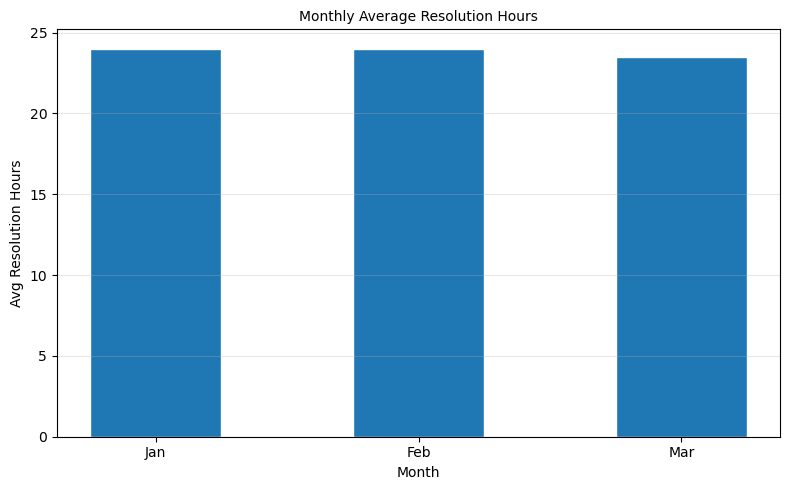

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(monthly_avg.index, monthly_avg.values, width=0.5, edgecolor='white')

ax.set_title('Monthly Average Resolution Hours', fontsize=10,)
ax.set_xlabel('Month')
ax.set_ylabel('Avg Resolution Hours')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()